<a href="https://colab.research.google.com/github/arghads9177/BERT-Fine-Tuning/blob/master/BERT_Text_Classification_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning BERT for Text Classification
### Hugging Face Learning Series — Step-by-Step Guide

---

## What You Will Learn
This notebook walks you through the **complete fine-tuning pipeline** for BERT on a text classification task:

| Step | What happens |
|---|---|
| 1 | Set up environment & GPU |
| 2 | Authenticate with Hugging Face Hub |
| 3 | Load a real dataset from Hugging Face |
| 4 | Explore & understand the dataset |
| 5 | Tokenize the dataset |
| 6 | Load BERT with a classification head |
| 7 | Define training arguments |
| 8 | Define evaluation metrics |
| 9 | Train the model (fine-tuning) |
| 10 | Evaluate the trained model |
| 11 | Run inference on new examples |
| 12 | Save the model locally |
| 13 | Push the model to Hugging Face Hub |
| 14 | Load and test the published model |

---

## Dataset
We use the **`ag_news`** dataset — a news topic classification benchmark with **4 classes**:
- `0` → World
- `1` → Sports
- `2` → Business
- `3` → Sci/Tech

It has 120,000 training samples and 7,600 test samples. We will use a subset for faster training.

---

> **Runtime:** Make sure you have selected **GPU** runtime.
> Go to `Runtime → Change runtime type → T4 GPU`

---
## Step 1 — Install & Import Libraries

In [1]:
# Install required libraries
# transformers  — BERT model, tokenizer, Trainer
# datasets      — load datasets from Hugging Face Hub
# evaluate      — compute metrics like accuracy, F1
# accelerate    — required by Trainer for GPU/CPU handling
# huggingface_hub — push model to Hub

!pip install -q transformers datasets evaluate accelerate huggingface_hub scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)
from huggingface_hub import notebook_login, HfApi

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version  : 2.10.0+cu128
CUDA available   : True
GPU device       : Tesla T4
GPU memory       : 15.6 GB


---
## Step 2 — Authenticate with Hugging Face Hub

You need a **Hugging Face account** and a **write-access token** to push your model.

**Get your token:**
1. Go to https://huggingface.co/settings/tokens
2. Click **New token**
3. Choose **Write** access
4. Copy the token and paste it below when prompted

In [3]:
# This opens a login widget — paste your HF write token when prompted
notebook_login()

In [4]:
# ── Configuration — change these to your preferences ──────────────────────────

HF_USERNAME    = "argha9177"          # Your Hugging Face username
MODEL_NAME     = "bert-base-uncased"          # Base model to fine-tune
DATASET_NAME   = "ag_news"                   # Dataset from HF Hub
REPO_NAME      = "bert-ag-news-classifier"   # Name of your published model repo
HF_REPO_ID     = f"{HF_USERNAME}/{REPO_NAME}"

# Training hyperparameters
MAX_LENGTH     = 128     # Max token length per sample (AG News headlines are short)
BATCH_SIZE     = 32      # Samples per training step (reduce to 16 if GPU OOM)
EPOCHS         = 3       # Number of full passes over training data
LEARNING_RATE  = 2e-5    # Standard BERT fine-tuning LR (2e-5 to 5e-5)
TRAIN_SUBSET   = 8000    # Use a subset for faster training (full = 120000)
EVAL_SUBSET    = 2000    # Use a subset for evaluation  (full = 7600)
WARMUP_RATIO   = 0.1     # 10% of steps used for LR warmup
WEIGHT_DECAY   = 0.01    # L2 regularization
SAVE_DIR       = "./bert-ag-news"            # Local save directory

# Label definitions for AG News
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
NUM_LABELS  = len(LABEL_NAMES)

print(f"Model     : {MODEL_NAME}")
print(f"Dataset   : {DATASET_NAME}")
print(f"Repo ID   : {HF_REPO_ID}")
print(f"Labels    : {LABEL_NAMES}")

Model     : bert-base-uncased
Dataset   : ag_news
Repo ID   : argha9177/bert-ag-news-classifier
Labels    : ['World', 'Sports', 'Business', 'Sci/Tech']


---
## Step 3 — Load the Dataset

We use `load_dataset()` to pull `ag_news` directly from the Hugging Face Hub.
The dataset is automatically cached locally after the first download.

In [5]:
# Load the full dataset
raw_dataset = load_dataset(DATASET_NAME)
print(raw_dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [6]:
# Take a subset for faster training
# shuffle(seed=42) ensures reproducibility — same rows every run
train_dataset = raw_dataset["train"].shuffle(seed=42).select(range(TRAIN_SUBSET))
eval_dataset  = raw_dataset["test"].shuffle(seed=42).select(range(EVAL_SUBSET))

print(f"Training samples   : {len(train_dataset)}")
print(f"Evaluation samples : {len(eval_dataset)}")

Training samples   : 8000
Evaluation samples : 2000


---
## Step 4 — Explore the Dataset

Always explore your data before training. Understand its structure,
label distribution, and text lengths — this guides your hyperparameter choices.

In [7]:
# Look at the dataset features
print("Dataset features:")
print(train_dataset.features)
print()

# Look at a few examples
print("Sample examples:")
print("-" * 60)
for i in range(4):
    sample = train_dataset[i]
    label  = LABEL_NAMES[sample['label']]
    print(f"[{label:8s}] {sample['text'][:100]}...")
print("-" * 60)

Dataset features:
{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}

Sample examples:
------------------------------------------------------------
[World   ] Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades...
[Sports  ] Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and...
[World   ] Will Putin #39;s Power Play Make Russia Safer? Outwardly, Russia has not changed since the barrage o...
[Sci/Tech] U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertisin...
------------------------------------------------------------


In [8]:
# Check label distribution — important to detect class imbalance
from collections import Counter

label_counts = Counter(train_dataset['label'])
print("Label distribution in training set:")
print("-" * 40)
for label_id, count in sorted(label_counts.items()):
    pct  = count / len(train_dataset) * 100
    bar  = '█' * int(pct / 2)
    print(f"  {LABEL_NAMES[label_id]:10s} (id={label_id}): {count:5d} samples ({pct:.1f}%) {bar}")
print()
print("AG News is a balanced dataset — each class has ~25% of samples.")
print("For imbalanced datasets, you would use weighted loss or oversampling.")

Label distribution in training set:
----------------------------------------
  World      (id=0):  2020 samples (25.2%) ████████████
  Sports     (id=1):  2027 samples (25.3%) ████████████
  Business   (id=2):  1892 samples (23.6%) ███████████
  Sci/Tech   (id=3):  2061 samples (25.8%) ████████████

AG News is a balanced dataset — each class has ~25% of samples.
For imbalanced datasets, you would use weighted loss or oversampling.


In [10]:
# Check text length distribution — helps choose MAX_LENGTH
text_lengths = [len(text.split()) for text in train_dataset['text']]
print("Text length statistics (in words):")
print(f"  Min    : {min(text_lengths)}")
print(f"  Max    : {max(text_lengths)}")
print(f"  Mean   : {np.mean(text_lengths):.1f}")
print(f"  Median : {np.median(text_lengths):.1f}")
print(f"  95th % : {np.percentile(text_lengths, 95):.1f}")
print()
print(f"Our MAX_LENGTH={MAX_LENGTH} tokens covers 95%+ of samples — good choice.")

Text length statistics (in words):
  Min    : 8
  Max    : 157
  Mean   : 37.7
  Median : 37.0
  95th % : 53.0

Our MAX_LENGTH=128 tokens covers 95%+ of samples — good choice.


---
## Step 5 — Tokenization

We convert raw text into token IDs that BERT understands.

**Key parameters:**
- `truncation=True` — cut texts longer than `max_length`
- `padding="max_length"` — pad shorter texts to `max_length`
- `max_length=128` — BERT supports up to 512; 128 is faster for short texts

We use `.map()` with `batched=True` to tokenize the entire dataset efficiently.

In [11]:
# Load the tokenizer — MUST match the model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded  : {MODEL_NAME}")
print(f"Vocabulary size   : {tokenizer.vocab_size}")
print(f"Max model length  : {tokenizer.model_max_length}")
print(f"Special tokens    : {tokenizer.all_special_tokens}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded  : bert-base-uncased
Vocabulary size   : 30522
Max model length  : 512
Special tokens    : ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [12]:
# Inspect what tokenization looks like on one sample
sample_text = train_dataset[0]['text']
print(f"Original text : {sample_text}")
print()

sample_enc = tokenizer(sample_text, truncation=True, max_length=MAX_LENGTH, padding="max_length")
tokens     = tokenizer.convert_ids_to_tokens(sample_enc['input_ids'])

print(f"Tokens        : {tokens[:20]}  ...")
print(f"Input IDs     : {sample_enc['input_ids'][:20]}  ...")
print(f"Attention mask: {sample_enc['attention_mask'][:20]}  ...")
print(f"Total length  : {len(sample_enc['input_ids'])}")

Original text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.

Tokens        : ['[CLS]', 'bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bangladesh', 'to', 'a', 'halt']  ...
Input IDs     : [101, 7269, 11498, 2135, 6924, 2011, 9326, 4559, 10134, 2031, 2716, 2116, 4865, 1998, 3655, 1999, 7269, 2000, 1037, 9190]  ...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  ...
Total length  : 128


In [13]:
# Define the tokenization function
def tokenize_function(examples):
    """
    Tokenize a batch of examples.
    The 'text' column in ag_news contains the news headline + description.
    """
    return tokenizer(
        examples['text'],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

# Apply tokenization to the entire dataset
# batched=True processes multiple samples at once — much faster
# remove_columns=['text'] removes the raw text column — model doesn't need it
print("Tokenizing training set...")
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

print("Tokenizing evaluation set...")
tokenized_eval = eval_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text']
)

print(f"\nTokenized training features  : {tokenized_train.features}")
print(f"Tokenized eval features      : {tokenized_eval.features}")

Tokenizing training set...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizing evaluation set...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Tokenized training features  : {'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Tokenized eval features      : {'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [14]:
# Set the format so the Trainer gets PyTorch tensors
tokenized_train.set_format("torch")
tokenized_eval.set_format("torch")

print("Dataset format set to PyTorch tensors.")
print(f"Sample keys    : {list(tokenized_train[0].keys())}")
print(f"input_ids shape: {tokenized_train[0]['input_ids'].shape}")

Dataset format set to PyTorch tensors.
Sample keys    : ['label', 'input_ids', 'token_type_ids', 'attention_mask']
input_ids shape: torch.Size([128])


---
## Step 6 — Load BERT with Classification Head

`AutoModelForSequenceClassification` loads BERT and attaches a
**linear classification head** on top of the `[CLS]` token output.

Architecture:
```
BERT Encoder (12 layers) → [CLS] vector (768-dim) → Dropout → Linear(768 → num_labels) → logits
```

You will see a warning: *"Some weights were not used..."* — this is **expected and normal**.
It means the pre-training head (MLM head) is discarded and replaced by the classification head.

In [15]:
# id2label and label2id let the model know the human-readable class names
# These are saved with the model and appear in pipeline outputs
id2label = {i: name for i, name in enumerate(LABEL_NAMES)}
label2id = {name: i for i, name in enumerate(LABEL_NAMES)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print(f"\nModel loaded: {MODEL_NAME}")
print(f"Num labels : {NUM_LABELS}")
print(f"id2label   : {id2label}")

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"\nClassification head  : {model.classifier}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded: bert-base-uncased
Num labels : 4
id2label   : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

Total parameters     : 109,485,316
Trainable parameters : 109,485,316

Classification head  : Linear(in_features=768, out_features=4, bias=True)


---
## Step 7 — Define Training Arguments

`TrainingArguments` controls every aspect of the training loop:
learning rate, batch size, epochs, evaluation strategy, checkpointing, and more.

**Key arguments explained:**

| Argument | Value | Why |
|---|---|---|
| `learning_rate` | 2e-5 | Standard for BERT fine-tuning (2e-5 to 5e-5) |
| `warmup_ratio` | 0.1 | Gradually increase LR for first 10% of steps |
| `weight_decay` | 0.01 | L2 regularization to prevent overfitting |
| `eval_strategy` | epoch | Evaluate after every epoch |
| `load_best_model_at_end` | True | Automatically restore best checkpoint |
| `fp16` | True | Mixed precision — faster & less GPU memory |

In [16]:
training_args = TrainingArguments(

    # ── Output & Logging ──────────────────────────────────────────────────
    output_dir=SAVE_DIR,                  # Where to save checkpoints
    logging_dir=f"{SAVE_DIR}/logs",       # TensorBoard logs
    logging_steps=50,                     # Log metrics every 50 steps
    report_to="none",                     # Disable W&B / other trackers

    # ── Training schedule ─────────────────────────────────────────────────
    num_train_epochs=EPOCHS,              # Total training epochs
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,            # LR warmup for first 10% of steps
    weight_decay=WEIGHT_DECAY,            # L2 regularization
    lr_scheduler_type="linear",           # LR decays linearly after warmup

    # ── Evaluation & Checkpointing ─────────────────────────────────────
    eval_strategy="epoch",                # Evaluate after each epoch
    save_strategy="epoch",                # Save checkpoint after each epoch
    load_best_model_at_end=True,          # Restore best model when done
    metric_for_best_model="accuracy",     # Choose best checkpoint by accuracy
    greater_is_better=True,

    # ── Performance ───────────────────────────────────────────────────────
    fp16=torch.cuda.is_available(),       # Use mixed precision on GPU
    dataloader_num_workers=2,
)

# Show how many steps per epoch
steps_per_epoch = len(tokenized_train) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f"Steps per epoch : {steps_per_epoch}")
print(f"Total steps     : {total_steps}")
print(f"Warmup steps    : {warmup_steps}")
print(f"Mixed precision : {torch.cuda.is_available()}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Steps per epoch : 250
Total steps     : 750
Warmup steps    : 75
Mixed precision : True


---
## Step 8 — Define Evaluation Metrics

We compute four metrics:
- **Accuracy** — overall correct predictions / total predictions
- **F1 (macro)** — average F1 across all classes (treats each class equally)
- **Precision (macro)** — correct positives / all predicted positives
- **Recall (macro)** — correct positives / all actual positives

> For balanced datasets like AG News, accuracy is a good primary metric.
> For imbalanced datasets, use macro F1 as the primary metric.

In [17]:
# Load metrics from the `evaluate` library
accuracy_metric  = evaluate.load("accuracy")
f1_metric        = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric    = evaluate.load("recall")

def compute_metrics(eval_pred):
    """
    Called by the Trainer after each evaluation.
    eval_pred is a tuple of (logits, labels).

    logits shape : [num_samples, num_labels]  — raw scores before softmax
    labels shape : [num_samples]              — true class indices
    """
    logits, labels = eval_pred

    # Convert logits → predicted class index (argmax)
    predictions = np.argmax(logits, axis=-1)

    acc  = accuracy_metric.compute(predictions=predictions, references=labels)
    f1   = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    prec = precision_metric.compute(predictions=predictions, references=labels, average="macro")
    rec  = recall_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy" : acc["accuracy"],
        "f1"       : f1["f1"],
        "precision": prec["precision"],
        "recall"   : rec["recall"],
    }

print("Metrics defined: accuracy, f1 (macro), precision (macro), recall (macro)")

Metrics defined: accuracy, f1 (macro), precision (macro), recall (macro)


---
## Step 9 — Train the Model (Fine-Tuning)

The `Trainer` orchestrates the entire training loop:
- Forward pass through BERT
- Compute cross-entropy loss
- Backward pass (gradient computation)
- Parameter update (AdamW optimizer)
- Learning rate scheduling
- Evaluation after each epoch
- Checkpointing

**What is happening during fine-tuning?**
- All 110M BERT parameters + the new classification head weights are updated
- BERT's pre-trained knowledge is **preserved and adapted** to your task
- The [CLS] token representation gradually specialises for news topic classification

In [18]:
# Build the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    # EarlyStoppingCallback stops training if accuracy doesn't improve
    # for 2 consecutive evaluations — prevents wasted compute
)

print("Trainer built successfully.")
print(f"Training on {len(tokenized_train)} samples for {EPOCHS} epochs...")

Trainer built successfully.
Training on 8000 samples for 3 epochs...


In [19]:
# ── START TRAINING ──────────────────────────────────────────────────────────
# This cell will take 5-15 minutes on a T4 GPU depending on subset size.
# You will see training loss, eval loss, and metrics printed after each epoch.

train_result = trainer.train()

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"Total training time   : {train_result.metrics['train_runtime']:.0f}s")
print(f"Samples per second    : {train_result.metrics['train_samples_per_second']:.1f}")
print(f"Final training loss   : {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.308560,0.317143,0.896500,0.897264,0.900468,0.898118
2,0.228494,0.276123,0.911000,0.912258,0.914176,0.911870
3,0.138478,0.283402,0.911000,0.911848,0.912226,0.912171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


TRAINING COMPLETE
Total training time   : 190s
Samples per second    : 126.6
Final training loss   : 0.3229


---
## Step 10 — Evaluate the Trained Model

Run a full evaluation on the test set and inspect per-class performance.

In [20]:
# Full evaluation on test set
eval_results = trainer.evaluate()

print("=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
for key, val in eval_results.items():
    print(f"  {key:<30s}: {val:.4f}")

EVALUATION RESULTS
  eval_loss                     : 0.2759
  eval_accuracy                 : 0.9110
  eval_f1                       : 0.9123
  eval_precision                : 0.9142
  eval_recall                   : 0.9119
  eval_runtime                  : 4.0870
  eval_samples_per_second       : 489.3510
  eval_steps_per_second         : 15.4150
  epoch                         : 3.0000


In [21]:
# Per-class classification report using sklearn
from sklearn.metrics import classification_report

# Get predictions on the full eval set
predictions_output = trainer.predict(tokenized_eval)
preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(labels, preds, target_names=LABEL_NAMES))

PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       0.96      0.87      0.92       497
      Sports       0.97      0.99      0.98       483
    Business       0.87      0.89      0.88       522
    Sci/Tech       0.85      0.90      0.88       498

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



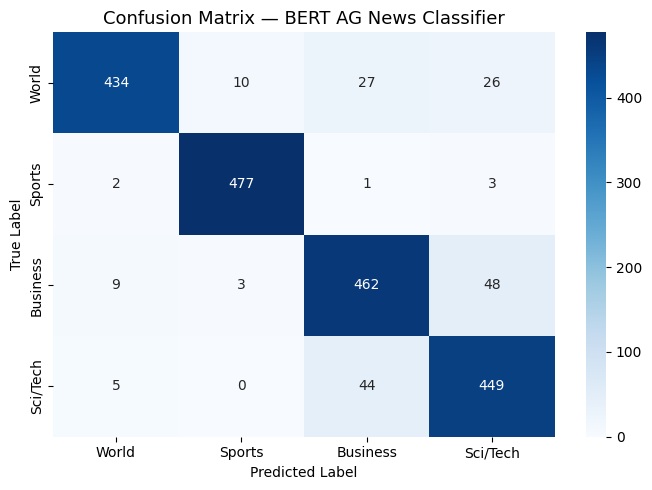

In [22]:
# Confusion matrix to see which classes get confused with each other
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES
)
plt.title('Confusion Matrix — BERT AG News Classifier', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

---
## Step 11 — Run Inference on New Examples

Test your fine-tuned model on custom sentences before saving and publishing.

In [23]:
# Manual inference — understand what's happening under the hood
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_sentences = [
    "Manchester United wins the Premier League championship in a thrilling final match.",
    "NASA launches new telescope to explore distant galaxies and dark matter.",
    "Federal Reserve raises interest rates to combat inflation in the US economy.",
    "World leaders gather at UN summit to discuss climate change agreements.",
    "Apple releases new iPhone model with advanced AI-powered camera features.",
    "Indian cricket team defeats Australia in the final Test match series.",
]

print("=" * 65)
print("INFERENCE ON CUSTOM SENTENCES")
print("=" * 65)

for sentence in test_sentences:
    # Tokenize
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    ).to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits → probabilities → predicted label
    probs      = torch.softmax(outputs.logits, dim=-1)[0]
    pred_id    = torch.argmax(probs).item()
    pred_label = LABEL_NAMES[pred_id]
    confidence = probs[pred_id].item()

    print(f"\n  Text       : {sentence[:70]}..." if len(sentence)>70 else f"\n  Text       : {sentence}")
    print(f"  Predicted  : {pred_label} (confidence: {confidence:.1%})")
    print(f"  All scores : " + " | ".join([f"{LABEL_NAMES[i]}: {probs[i]:.2%}" for i in range(NUM_LABELS)]))

INFERENCE ON CUSTOM SENTENCES

  Text       : Manchester United wins the Premier League championship in a thrilling ...
  Predicted  : Sports (confidence: 97.2%)
  All scores : World: 2.44% | Sports: 97.17% | Business: 0.22% | Sci/Tech: 0.17%

  Text       : NASA launches new telescope to explore distant galaxies and dark matte...
  Predicted  : Sci/Tech (confidence: 98.6%)
  All scores : World: 0.53% | Sports: 0.29% | Business: 0.58% | Sci/Tech: 98.60%

  Text       : Federal Reserve raises interest rates to combat inflation in the US ec...
  Predicted  : Business (confidence: 96.3%)
  All scores : World: 2.54% | Sports: 0.31% | Business: 96.28% | Sci/Tech: 0.88%

  Text       : World leaders gather at UN summit to discuss climate change agreements...
  Predicted  : Sci/Tech (confidence: 94.0%)
  All scores : World: 4.77% | Sports: 0.58% | Business: 0.64% | Sci/Tech: 94.02%

  Text       : Apple releases new iPhone model with advanced AI-powered camera featur...
  Predicted  : Sci/Tec

In [24]:
# Even simpler — use Hugging Face pipeline for inference
# This is what end-users will do after you publish the model

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

print("Pipeline inference:")
results = classifier(test_sentences)
for sentence, result in zip(test_sentences, results):
    print(f"  [{result['label']:10s} | {result['score']:.2%}] {sentence[:70]}")

Pipeline inference:
  [Sports     | 97.17%] Manchester United wins the Premier League championship in a thrilling 
  [Sci/Tech   | 98.60%] NASA launches new telescope to explore distant galaxies and dark matte
  [Business   | 96.27%] Federal Reserve raises interest rates to combat inflation in the US ec
  [Sci/Tech   | 94.02%] World leaders gather at UN summit to discuss climate change agreements
  [Sci/Tech   | 98.24%] Apple releases new iPhone model with advanced AI-powered camera featur
  [Sports     | 52.00%] Indian cricket team defeats Australia in the final Test match series.


---
## Step 12 — Save the Model Locally

Save everything needed to reload and use the model:
- Model weights (`pytorch_model.bin` or `model.safetensors`)
- Model config (`config.json`) — architecture, labels, hyperparams
- Tokenizer files — vocabulary, special tokens, tokenizer config

With these three components, anyone can reload your model without internet.

In [25]:
import os

FINAL_SAVE_DIR = "./bert-ag-news-final"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)

# Save model weights + config
model.save_pretrained(FINAL_SAVE_DIR)

# Save tokenizer
tokenizer.save_pretrained(FINAL_SAVE_DIR)

# List what was saved
print(f"Model saved to: {FINAL_SAVE_DIR}")
print("\nSaved files:")
for f in sorted(os.listdir(FINAL_SAVE_DIR)):
    size = os.path.getsize(f"{FINAL_SAVE_DIR}/{f}")
    print(f"  {f:<40s} {size/1e6:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./bert-ag-news-final

Saved files:
  config.json                              0.0 MB
  model.safetensors                        438.0 MB
  tokenizer.json                           0.7 MB
  tokenizer_config.json                    0.0 MB


In [26]:
# Verify local save — reload and run inference to confirm everything works
print("Verifying saved model by reloading it...")

reloaded_model     = AutoModelForSequenceClassification.from_pretrained(FINAL_SAVE_DIR)
reloaded_tokenizer = AutoTokenizer.from_pretrained(FINAL_SAVE_DIR)

verify_pipeline = pipeline(
    "text-classification",
    model=reloaded_model,
    tokenizer=reloaded_tokenizer
)

test_text   = "SpaceX successfully launches 60 Starlink satellites into orbit."
test_result = verify_pipeline(test_text)

print(f"\nTest text  : {test_text}")
print(f"Prediction : {test_result}")
print("\nLocal save verified successfully!")

Verifying saved model by reloading it...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Test text  : SpaceX successfully launches 60 Starlink satellites into orbit.
Prediction : [{'label': 'Sci/Tech', 'score': 0.9859334826469421}]

Local save verified successfully!


---
## Step 13 — Write a Model Card

A **model card** is a `README.md` file that documents:
- What the model does
- How it was trained
- How to use it
- Its performance metrics

It appears on your Hugging Face Hub model page. Good model cards make your
model discoverable, understandable, and reusable by others.

In [27]:
# Extract final evaluation metrics to include in the model card
final_accuracy  = eval_results.get('eval_accuracy', 0)
final_f1        = eval_results.get('eval_f1', 0)
final_precision = eval_results.get('eval_precision', 0)
final_recall    = eval_results.get('eval_recall', 0)

model_card = f"""---
language: en
license: apache-2.0
base_model: bert-base-uncased
tags:
  - text-classification
  - bert
  - news
  - ag_news
datasets:
  - ag_news
metrics:
  - accuracy
  - f1
---

# BERT AG News Classifier

A fine-tuned version of `bert-base-uncased` on the [AG News](https://huggingface.co/datasets/ag_news)
dataset for **4-class news topic classification**.

## Labels
| ID | Label |
|---|---|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

## Model Performance
Evaluated on {EVAL_SUBSET} samples from the AG News test set:

| Metric | Score |
|---|---|
| Accuracy | {final_accuracy:.4f} |
| F1 (macro) | {final_f1:.4f} |
| Precision (macro) | {final_precision:.4f} |
| Recall (macro) | {final_recall:.4f} |

## How to Use

```python
from transformers import pipeline

classifier = pipeline("text-classification", model="{HF_REPO_ID}")

result = classifier("NASA launches new space telescope to study dark matter.")
print(result)
# [{{'label': 'Sci/Tech', 'score': 0.97}}]
```

## Training Details

| Parameter | Value |
|---|---|
| Base model | bert-base-uncased |
| Dataset | ag_news |
| Training samples | {TRAIN_SUBSET} |
| Epochs | {EPOCHS} |
| Batch size | {BATCH_SIZE} |
| Learning rate | {LEARNING_RATE} |
| Max length | {MAX_LENGTH} |
| Warmup ratio | {WARMUP_RATIO} |
| Weight decay | {WEIGHT_DECAY} |
| Optimizer | AdamW |
| LR scheduler | Linear with warmup |

## Training Framework
Trained using Hugging Face `Trainer` API with `transformers=={__import__('transformers').__version__}`.
"""

# Save the model card
with open(f"{FINAL_SAVE_DIR}/README.md", "w") as f:
    f.write(model_card)

print("Model card written to README.md")
print(f"Preview:\n{model_card[:500]}...")

Model card written to README.md
Preview:
---
language: en
license: apache-2.0
base_model: bert-base-uncased
tags:
  - text-classification
  - bert
  - news
  - ag_news
datasets:
  - ag_news
metrics:
  - accuracy
  - f1
---

# BERT AG News Classifier

A fine-tuned version of `bert-base-uncased` on the [AG News](https://huggingface.co/datasets/ag_news)
dataset for **4-class news topic classification**.

## Labels
| ID | Label |
|---|---|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

## Model Performance
Evaluated on 200...


---
## Step 14 — Push to Hugging Face Hub

Publishing your model to the Hub makes it:
- Publicly accessible via `pipeline(model="your-username/repo-name")`
- Versioned with Git
- Searchable on huggingface.co
- Downloadable by anyone worldwide

The push uploads model weights, config, tokenizer files, and the README.

In [28]:
# Create the repository on Hub (if it doesn't exist yet)
api = HfApi()

try:
    api.create_repo(repo_id=HF_REPO_ID, exist_ok=True)
    print(f"Repository ready: https://huggingface.co/{HF_REPO_ID}")
except Exception as e:
    print(f"Repo creation note: {e}")

Repository ready: https://huggingface.co/argha9177/bert-ag-news-classifier


In [29]:
# Push model weights + config
print("Pushing model to Hub...")
model.push_to_hub(
    HF_REPO_ID,
    commit_message="Add fine-tuned BERT AG News classifier"
)

# Push tokenizer
print("Pushing tokenizer to Hub...")
tokenizer.push_to_hub(
    HF_REPO_ID,
    commit_message="Add tokenizer"
)

# Push README (model card)
print("Pushing model card to Hub...")
api.upload_file(
    path_or_fileobj=f"{FINAL_SAVE_DIR}/README.md",
    path_in_repo="README.md",
    repo_id=HF_REPO_ID,
    commit_message="Add model card"
)

print("\n" + "=" * 55)
print("MODEL PUBLISHED SUCCESSFULLY")
print("=" * 55)
print(f"View at : https://huggingface.co/{HF_REPO_ID}")

Pushing model to Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_iaclg/model.safetensors:   0%|          | 14.2kB /  438MB            

Pushing tokenizer to Hub...


README.md: 0.00B [00:00, ?B/s]

Pushing model card to Hub...

MODEL PUBLISHED SUCCESSFULLY
View at : https://huggingface.co/argha9177/bert-ag-news-classifier


---
## Step 15 — Load and Test the Published Model

The ultimate test — load your model **from the Hub** exactly as any user would.
If this works, your model is live and working for the world.

In [30]:
# Load directly from Hugging Face Hub (as any user would)
print(f"Loading published model from: {HF_REPO_ID}")

published_classifier = pipeline(
    "text-classification",
    model=HF_REPO_ID
)

# Final test sentences
final_tests = [
    "Virat Kohli breaks the world record for most ODI centuries.",
    "Google announces Gemini Ultra, its most powerful AI model yet.",
    "Oil prices surge as OPEC announces production cuts.",
    "G20 leaders agree on new framework to address global poverty.",
]

print("\n" + "=" * 65)
print("FINAL INFERENCE FROM PUBLISHED HUB MODEL")
print("=" * 65)

results = published_classifier(final_tests)
for text, result in zip(final_tests, results):
    print(f"\n  Text  : {text}")
    print(f"  Label : {result['label']}  ({result['score']:.2%} confidence)")

Loading published model from: argha9177/bert-ag-news-classifier


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


FINAL INFERENCE FROM PUBLISHED HUB MODEL

  Text  : Virat Kohli breaks the world record for most ODI centuries.
  Label : Sports  (95.66% confidence)

  Text  : Google announces Gemini Ultra, its most powerful AI model yet.
  Label : Sci/Tech  (95.55% confidence)

  Text  : Oil prices surge as OPEC announces production cuts.
  Label : Business  (96.65% confidence)

  Text  : G20 leaders agree on new framework to address global poverty.
  Label : World  (94.66% confidence)


---
## Summary — What I Just Built

```
Raw text (AG News)
     ↓
Tokenization (bert-base-uncased tokenizer)
     ↓
BERT Encoder (12 layers, 110M parameters)
     ↓
[CLS] vector (768-dim)
     ↓
Linear head (768 → 4)
     ↓
Softmax → [World, Sports, Business, Sci/Tech]
```

---

## Key Concepts Reinforced

| Concept | Where you used it |
|---|---|
| `[CLS]` token | Classification head reads only this vector |
| Tokenizer must match model | Loaded both from `bert-base-uncased` |
| Attention mask | Produced by tokenizer, passed to model |
| `AutoModelForSequenceClassification` | BERT + linear head, pre-assembled |
| Logits → probabilities | `torch.softmax(logits, dim=-1)` |
| Fine-tuning = transfer learning | Pre-trained weights adapted to new task |
| Model card | Documents your model for other users |

---
## Model Repo in Huggingface

https://huggingface.co/argha9177/bert-ag-news-classifier